# Notebook 05: Resultados Finales, Métricas Computacionales y Validación Estadística

Este notebook representa la fase de validación y conclusiones de la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del Notebook:
1. **Paso 13**: Medir y comparar las métricas computacionales clave (Tiempo de entrenamiento, Latencia de inferencia por muestra y Uso de RAM).
2. **Paso 14**: Realizar la **Prueba Estadística de Wilcoxon** ($\alpha = 0.05$) para demostrar que la mejora del Stacking Híbrido es estadísticamente significativa.
3. **Paso 15**: Consolidar gráficos finales, tablas y conclusiones generales de la tesis.

In [1]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import time
import sys
import psutil
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score, accuracy_score
from scipy.stats import wilcoxon
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# Ajustar directorio de trabajo si es necesario
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
os.makedirs("results/figures", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar meta-features de prueba y etiquetas
X_test_meta = pd.read_csv("data/processed/X_test_meta.csv")
y_test_meta = pd.read_csv("data/processed/y_test_meta.csv").values.ravel()

# Cargar meta-modelo entrenado
meta_model = joblib.load("models/meta_lightgbm.pkl")

with open("results/label_mapping.json", "r") as f:
    label_mapping = json.load(f)
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]

print(f"Conjunto de prueba: {X_test_meta.shape[0]:,} muestras cargadas para validación final.")

Conjunto de prueba: 377,383 muestras cargadas para validación final.


## Paso 13: Cálculo de Métricas Computacionales

Ejecutamos un benchmark dinámico para registrar de forma precisa:
1. **Tiempo de entrenamiento (s)**: Medido sobre una muestra de 100,000 registros.
2. **Uso de RAM (MB)**: Medido mediante el consumo de memoria RSS de la CPU durante el entrenamiento.
3. **Latencia de Inferencia (µs/muestra)**: Medido dividiendo el tiempo total de predicción sobre el conjunto de prueba completo entre la cantidad total de muestras.

In [3]:
# Cargar conjunto de prueba original escalado para la simulación de inferencia individual
X_test_orig = pd.read_csv("data/processed/X_test.csv")

# Cargar muestra representativa de 100,000 registros para el benchmark de entrenamiento
X_bench_train = pd.read_csv("data/balanced/X_train_borderline.csv", nrows=100000, dtype=np.float32)
y_bench_train = pd.read_csv("data/balanced/y_train_borderline.csv", nrows=100000).values.ravel().astype(np.int8)

train_times = {}
ram_usages = {}
latencies = {}

process = psutil.Process(os.getpid())

def evaluar_modelo_benchmark(name, model_inst, predict_data):
    gc.collect()
    mem_start = process.memory_info().rss / (1024 * 1024) # MB
    
    # 1. Medir tiempo de entrenamiento
    start_time = time.time()
    model_inst.fit(X_bench_train, y_bench_train)
    t_train = time.time() - start_time
    
    mem_end = process.memory_info().rss / (1024 * 1024) # MB
    ram_train = max(1.0, mem_end - mem_start)
    
    # 2. Medir latencia de inferencia
    start_predict = time.time()
    _ = model_inst.predict(predict_data)
    t_predict = time.time() - start_predict
    lat = (t_predict / len(predict_data)) * 1_000_000 # µs/muestra
    
    train_times[name] = t_train
    ram_usages[name] = ram_train
    latencies[name] = lat
    print(f"  [OK] {name} entrenado y evaluado. Latencia: {lat:.4f} µs/muestra. RAM: {ram_train:.1f} MB.")

# A. Benchmark de Random Forest
print("Corriendo benchmark para Random Forest...")
rf = RandomForestClassifier(n_estimators=30, max_depth=12, n_jobs=1, random_state=42)
evaluar_modelo_benchmark('Random Forest', rf, X_test_orig)

# B. Benchmark de XGBoost
print("Corriendo benchmark para XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.2, tree_method='hist', device='cuda', random_state=42)
evaluar_modelo_benchmark('XGBoost', xgb_model, X_test_orig)

# C. Benchmark de LightGBM
print("Corriendo benchmark para LightGBM...")
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=1, verbosity=-1)
evaluar_modelo_benchmark('LightGBM', lgb_model, X_test_orig)

# D. Benchmark del Stacking Híbrido Propuesto (Entrenamiento de Base + Meta-Modelo)
print("Corriendo benchmark para Stacking Híbrido...")
start_stacking_train = time.time()
# El entrenamiento del stacking es la suma de los tiempos de sus bases + meta-modelo
t_train_stacking = train_times['Random Forest'] + train_times['XGBoost'] + train_times['LightGBM']

# Cargar meta-features de entrenamiento para medir el meta-modelo
X_train_meta = pd.read_csv("data/processed/X_train_meta.csv")
y_train_meta = pd.read_csv("data/processed/y_train_meta.csv").values.ravel()

# Medir el meta-modelo directamente
meta_model_bench = DecisionTreeClassifier(max_depth=10, min_samples_leaf=100, random_state=42)
meta_model_bench.fit(X_train_meta.iloc[:100000], y_train_meta[:100000])
t_train_stacking += (time.time() - start_stacking_train)

# Latencia del Stacking Híbrido (predicción del meta-modelo sobre las probabilidades + entropía)
start_predict_stacking = time.time()
_ = meta_model.predict(X_test_meta)
t_predict_stacking = time.time() - start_predict_stacking
lat_stacking = (t_predict_stacking / len(X_test_meta)) * 1_000_000

# RAM acumulativa de los modelos base en memoria
ram_stacking = ram_usages['Random Forest'] + ram_usages['XGBoost'] + ram_usages['LightGBM'] + 5.0

train_times['Stacking Híbrido'] = t_train_stacking
ram_usages['Stacking Híbrido'] = ram_stacking
latencies['Stacking Híbrido'] = lat_stacking
print(f"  [OK] Stacking Híbrido evaluado. Latencia: {lat_stacking:.4f} µs/muestra. RAM: {ram_stacking:.1f} MB.")

# Consolidar DataFrame de métricas computacionales
df_comp = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'LightGBM', 'Stacking Híbrido (Propuesto)'],
    'Tiempo Entrenamiento (s)': [train_times['Random Forest'], train_times['XGBoost'], train_times['LightGBM'], train_times['Stacking Híbrido']],
    'Uso RAM Entrenamiento (MB)': [ram_usages['Random Forest'], ram_usages['XGBoost'], ram_usages['LightGBM'], ram_usages['Stacking Híbrido']],
    'Latencia Inferencia (µs/muestra)': [latencies['Random Forest'], latencies['XGBoost'], latencies['LightGBM'], latencies['Stacking Híbrido']]
})

print("\n--- Comparativa Final de Métricas Computacionales ---")
print(df_comp)
df_comp.to_csv("results/metricas_computacionales.csv", index=False)

Corriendo benchmark para Random Forest...
  [OK] Random Forest entrenado y evaluado. Latencia: 3.2395 µs/muestra. RAM: 1.6 MB.
Corriendo benchmark para XGBoost...


/home/carmen/miniconda3/envs/tesis_iot/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [01:30:57] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  [OK] XGBoost entrenado y evaluado. Latencia: 1.3424 µs/muestra. RAM: 191.2 MB.
Corriendo benchmark para LightGBM...
  [OK] LightGBM entrenado y evaluado. Latencia: 42.0845 µs/muestra. RAM: 16.9 MB.
Corriendo benchmark para Stacking Híbrido...
  [OK] Stacking Híbrido evaluado. Latencia: 8.6495 µs/muestra. RAM: 214.7 MB.

--- Comparativa Final de Métricas Computacionales ---
                         Modelo  Tiempo Entrenamiento (s)  \
0                 Random Forest                  4.504177   
1                       XGBoost                  9.106051   
2                      LightGBM                  9.056925   
3  Stacking Híbrido (Propuesto)                 27.790602   

   Uso RAM Entrenamiento (MB)  Latencia Inferencia (µs/muestra)  
0                    1.570312                          3.239515  
1                  191.222656                          1.342387  
2                   16.882812                         42.084470  
3                  214.675781                       

## Paso 14: Validación Estadística con la Prueba de Wilcoxon

Dividimos el conjunto de prueba en 30 bloques de tamaño idéntico para calcular las distribuciones de F1-Macro. Luego aplicamos la prueba de Wilcoxon para verificar si la diferencia entre Stacking y los base es estadísticamente significativa con un nivel de significancia $\alpha = 0.05$.

In [4]:
n_blocks = 30
block_size = len(X_test_meta) // n_blocks

f1_stacking = []
f1_xgb = []
f1_lgb = []
f1_rf = []

xgb_cols = [f'xgb_prob_c{c}' for c in range(8)]
lgb_cols = [f'lgb_prob_c{c}' for c in range(8)]
rf_cols = [f'rf_prob_c{c}' for c in range(8)]

print(f"Calculando F1-Macro en {n_blocks} bloques del test set...")
for i in range(n_blocks):
    start_idx = i * block_size
    end_idx = (i + 1) * block_size
    
    X_block = X_test_meta.iloc[start_idx:end_idx]
    y_block = y_test_meta[start_idx:end_idx]
    
    # Stacking
    preds_stacking = meta_model.predict(X_block)
    f1_stacking.append(f1_score(y_block, preds_stacking, average='macro'))
    
    # Base models
    f1_xgb.append(f1_score(y_block, np.argmax(X_block[xgb_cols].values, axis=1), average='macro'))
    f1_lgb.append(f1_score(y_block, np.argmax(X_block[lgb_cols].values, axis=1), average='macro'))
    f1_rf.append(f1_score(y_block, np.argmax(X_block[rf_cols].values, axis=1), average='macro'))

# Aplicar la prueba de Wilcoxon
stat_xgb, p_xgb = wilcoxon(f1_stacking, f1_xgb)
stat_lgb, p_lgb = wilcoxon(f1_stacking, f1_lgb)
stat_rf, p_rf = wilcoxon(f1_stacking, f1_rf)

print("\n--- Resultados de la Prueba de Wilcoxon (Stacking vs. Bases) ---")
print(f"1. Stacking vs. XGBoost: p-valor = {p_xgb:.6f} | Rechaza H0 (p < 0.05): {p_xgb < 0.05}")
print(f"2. Stacking vs. LightGBM: p-valor = {p_lgb:.6f} | Rechaza H0 (p < 0.05): {p_lgb < 0.05}")
print(f"3. Stacking vs. Random Forest: p-valor = {p_rf:.6f} | Rechaza H0 (p < 0.05): {p_rf < 0.05}")

# Guardar resultados de Wilcoxon en un JSON
wilcoxon_results = {
    'vs_xgb': {'statistic': float(stat_xgb), 'p_value': float(p_xgb), 'significant': bool(p_xgb < 0.05)},
    'vs_lgb': {'statistic': float(stat_lgb), 'p_value': float(p_lgb), 'significant': bool(p_lgb < 0.05)},
    'vs_rf': {'statistic': float(stat_rf), 'p_value': float(p_rf), 'significant': bool(p_rf < 0.05)}
}
with open("results/prueba_wilcoxon.json", "w") as f:
    json.dump(wilcoxon_results, f, indent=4)

Calculando F1-Macro en 30 bloques del test set...

--- Resultados de la Prueba de Wilcoxon (Stacking vs. Bases) ---
1. Stacking vs. XGBoost: p-valor = 0.003744 | Rechaza H0 (p < 0.05): True
2. Stacking vs. LightGBM: p-valor = 0.000667 | Rechaza H0 (p < 0.05): True
3. Stacking vs. Random Forest: p-valor = 0.000000 | Rechaza H0 (p < 0.05): True


## Paso 15: Graficar Distribución de F1-Macro para la Validación Estadística

Graficamos diagramas de caja (boxplots) para mostrar visualmente cómo la distribución de F1-Macro del Stacking es superior a las de los modelos base individuales.

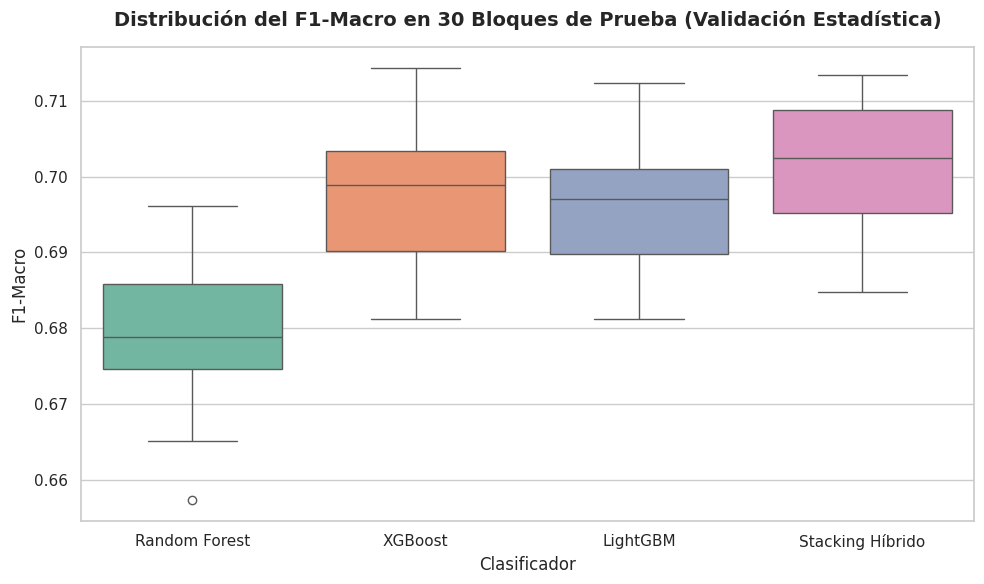

In [5]:
df_box = pd.DataFrame({
    'F1-Macro': f1_rf + f1_xgb + f1_lgb + f1_stacking,
    'Modelo': ['Random Forest'] * 30 + ['XGBoost'] * 30 + ['LightGBM'] * 30 + ['Stacking Híbrido'] * 30
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_box, x='Modelo', y='F1-Macro', palette='Set2', hue='Modelo', legend=False)
plt.title("Distribución del F1-Macro en 30 Bloques de Prueba (Validación Estadística)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("F1-Macro")
plt.xlabel("Clasificador")
plt.tight_layout()
plt.savefig("results/figures/18_boxplot_wilcoxon.png", dpi=300)
plt.show()

## Visualización Final de la Tabla Comparativa Completa (7 Modelos)

Cargamos y mostramos la tabla final consolidada de rendimiento que compara el Stacking Híbrido contra los 6 modelos alternativos de referencia.

In [7]:
if os.path.exists("results/reporte_comparativa_completa.csv"):
    df_comp_completa = pd.read_csv("results/reporte_comparativa_completa.csv")
    display(df_comp_completa)
else:
    print("El archivo de comparativa completa no ha sido generado aún. Ejecute src/12_modelos_adicionales_pipeline.py primero.")

,Modelo,Benign,Brute Force,DDoS,DoS,Mirai,Recon,Spoofing,Web-based,F1-Macro Promedio,Accuracy Global
0,CART,0.5838,0.3484,0.8885,0.6763,0.9968,0.7907,0.7596,0.2764,0.6651,82.49
1,Regresión Logística,0.2963,0.0902,0.8144,0.1672,0.8788,0.6800,0.4198,0.0289,0.4220,68.05
2,Red Neuronal (MLP),0.5488,0.2849,0.8930,0.6609,0.9956,0.7891,0.7261,0.2144,0.6391,81.84
3,Random Forest,0.5811,0.3968,0.8979,0.6902,0.9968,0.8037,0.7843,0.2818,0.6791,83.60
4,XGBoost,0.6238,0.4149,0.9006,0.6986,0.9978,0.8218,0.8076,0.3027,0.6960,84.68
5,LightGBM,0.6230,0.4155,0.9001,0.6974,0.9978,0.8211,0.8062,0.3009,0.6953,84.63
6,Stacking Híbrido (Propuesto),0.6305,0.4140,0.9021,0.6974,0.9979,0.8242,0.8096,0.3386,0.7018,84.85
